In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Modelos de Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# ==========================================
# 1. CARREGAMENTO E CRIAÇÃO DO ALVO (CIUR)
# ==========================================

# 1.1 Carrega os dados dos pacientes
df = pd.read_csv('accepted_PIDS_final_para_modelo.csv')

# 1.2 Carrega a tabela de referência
df_tabela_peso = pd.read_csv('Table1.csv')

# 1.3 Cria uma coluna temporária arredondando a 'IG no exame' para baixo 
df['IG_arredondada'] = df['IG no exame'].apply(np.floor)

# 1.4 Cruza os dados: Junta a tabela do paciente com a tabela de percentil
df = df.merge(df_tabela_peso, left_on='IG_arredondada', right_on='Menstrual Week', how='left')

# 1.5 Cria a regra do CIUR: Se o peso do feto for menor que o percentil 10 daquela semana, CIUR = 1 (True)
df['CIUR'] = (df[' (4) (2)'] < df['10th Percentile (g)']).astype(int)

print("Distribuição de CIUR no dataset:")
print(df['CIUR'].value_counts(normalize=True) * 100)
print("-" * 40)

# ==========================================
# 2. PREPARAÇÃO PARA O MACHINE LEARNING
# ==========================================

# Separa a variável de identificação para o agrupamento
grupos_pids = df['PID']

# Separa o alvo (o que queremos prever)
y = df['CIUR']

# Define quais colunas devem ser ESCONDIDAS do modelo para evitar "Data Leakage" (Vazamento)
colunas_para_remover = [
    'PID', 
    'CIUR', 
    ' (4) (2)', 
    'row_is_virtual', 
    'IG_arredondada',
    'Menstrual Week', 
    '3rd Percentile (g)', 
    '10th Percentile (g)', 
    '50th Percentile (g)', 
    '90th Percentile (g)', 
    '97th Percentile (g)',
    'IG exame'
]

# Cria o conjunto de variáveis preditoras (Features)
X = df.drop(columns=colunas_para_remover, errors='ignore')

# ==========================================
# 3. PIPELINE DE MODELOS E AVALIAÇÃO
# ==========================================
# Calcula o peso da classe minoritária (Quantos '0' existem para cada '1')
razao_desbalanceamento = len(df[df['CIUR'] == 0]) / len(df[df['CIUR'] == 1])

modelos = {
    # class_weight='balanced' ajusta o peso automaticamente
    'Regressão Logística': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(), # KNN não aceita pesos nativamente desta forma
    
    # scale_pos_weight é a forma do XGBoost dar peso aos casos raros (CIUR)
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=razao_desbalanceamento)
}

# Configura a validação cruzada agrupando por PID para o modelo nunca "decorar" o paciente
gkf = GroupKFold(n_splits=5)
resultados = []

print("\nIniciando o treinamento dos 4 modelos. Isso pode levar alguns segundos...\n")

for nome_modelo, modelo in modelos.items():
    # Pipeline organiza os passos de limpeza final e padronização antes de treinar
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Preenche Nulos residuais
        ('scaler', StandardScaler()),                  # Deixa as medidas na mesma escala
        ('classifier', modelo)                         # Aplica o modelo
    ])
    
    # Treina e testa 5 vezes
    cv_results = cross_validate(
        pipeline, X, y, groups=grupos_pids, cv=gkf,
        scoring=['accuracy', 'roc_auc', 'f1'], 
        n_jobs=-1
    )
    
    # Salva as médias
    resultados.append({
        'Modelo': nome_modelo,
        'Acurácia': round(cv_results['test_accuracy'].mean(), 4),
        'ROC AUC': round(cv_results['test_roc_auc'].mean(), 4),
        'F1-Score': round(cv_results['test_f1'].mean(), 4)
    })

# ==========================================
# 4. EXIBIR RANKING FINAIS
# ==========================================

df_resultados = pd.DataFrame(resultados).sort_values(by='ROC AUC', ascending=False)
print("=== RANKING DOS MODELOS ===")
print(df_resultados.to_markdown(index=False))

Distribuição de CIUR no dataset:
CIUR
0    98.095248
1     1.904752
Name: proportion, dtype: float64
----------------------------------------

Iniciando o treinamento dos 4 modelos. Isso pode levar alguns segundos...

=== RANKING DOS MODELOS ===
| Modelo              |   Acurácia |   ROC AUC |   F1-Score |
|:--------------------|-----------:|----------:|-----------:|
| XGBoost             |     0.939  |    0.9697 |     0.3506 |
| Random Forest       |     0.9842 |    0.9431 |     0.4403 |
| Regressão Logística |     0.8424 |    0.9296 |     0.1792 |
| KNN                 |     0.9835 |    0.8536 |     0.4359 |


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18440\1925806667.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancias, x='Importância (%)', y='Medida (Feature)', palette='viridis')


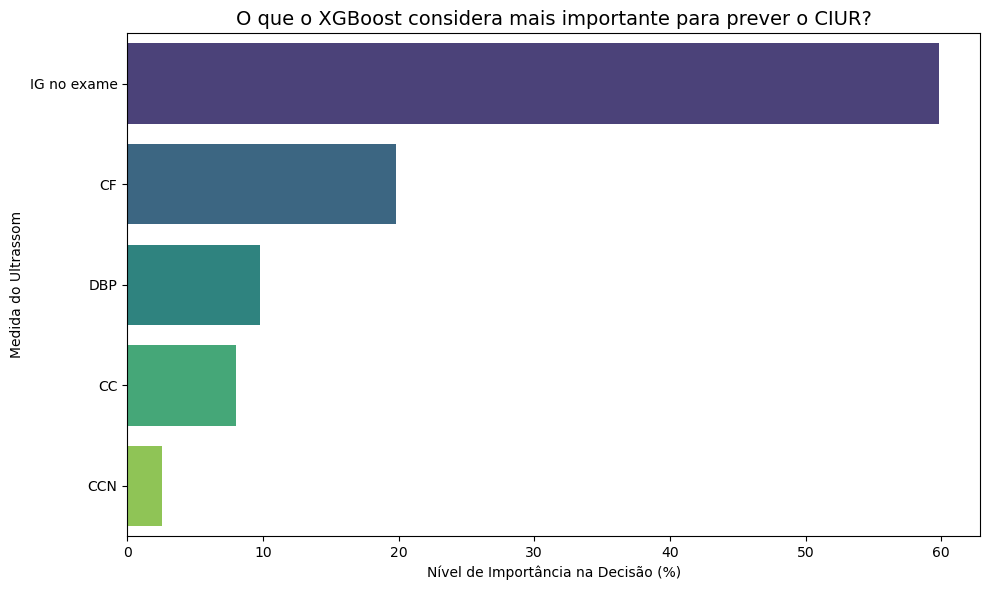

=== RANKING DE IMPORTÂNCIA DAS MEDIDAS ===
| Medida (Feature)   |   Importância (%) |
|:-------------------|------------------:|
| IG no exame        |          59.857   |
| CF                 |          19.7929  |
| DBP                |           9.77419 |
| CC                 |           7.99819 |
| CCN                |           2.57775 |


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Instanciamos o modelo campeão com os pesos ajustados
modelo_final = XGBClassifier(
    random_state=42, 
    eval_metric='logloss', 
    scale_pos_weight=razao_desbalanceamento
)

# Precisamos do Imputer para garantir que não haja NaN antes de treinar
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Treinamos o modelo com a base toda
modelo_final.fit(X_imputed, y)

# Extraímos a importância das variáveis
importancias = modelo_final.feature_importances_

# Criamos um DataFrame para visualizar melhor
df_importancias = pd.DataFrame({
    'Medida (Feature)': X.columns,
    'Importância (%)': importancias * 100
}).sort_values(by='Importância (%)', ascending=False)

# Exibindo o Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancias, x='Importância (%)', y='Medida (Feature)', palette='viridis')
plt.title('O que o XGBoost considera mais importante para prever o CIUR?', fontsize=14)
plt.xlabel('Nível de Importância na Decisão (%)')
plt.ylabel('Medida do Ultrassom')
plt.tight_layout()
plt.show()

# Imprime a tabelinha também
print("=== RANKING DE IMPORTÂNCIA DAS MEDIDAS ===")
print(df_importancias.to_markdown(index=False))

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Carregar os dados limpos
df = pd.read_csv('accepted_PIDS_final_para_modelo.csv')

# 2. Selecionar apenas as colunas do nosso experimento
colunas_experimento = ['CCN', 'CC', 'CF', 'DBP']
df_reg = df[colunas_experimento].copy()

# 3. Filtrar os dados reais
# Vamos manter APENAS as linhas onde o médico mediu as 4 coisas no mesmo ultrassom
df_reg = df_reg.dropna()

print(f"Total de exames com as 4 medidas (CCN, CC, CF, DBP) preenchidas: {len(df_reg)}\n")

if len(df_reg) < 15:
    print("Aviso: Existem pouquíssimas linhas com as 4 medidas juntas. O modelo não terá dados suficientes para aprender!")
else:
    # 4. Separar o Alvo (y) e as Dicas (X)
    X = df_reg[['CC', 'CF', 'DBP']] # Dicas: Tamanho da cabeça e do fêmur
    y = df_reg['CCN']               # Alvo: Tentar adivinhar o comprimento total

    # Misturar e separar 80% para o modelo estudar e 20% para a prova
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 5. Treinar os modelos
    
    # Modelo 1: Regressão Linear (Cria uma equação matemática simples)
    modelo_lr = LinearRegression()
    modelo_lr.fit(X_train, y_train)
    y_pred_lr = modelo_lr.predict(X_test)

    # Modelo 2: Random Forest Regressor (Cria árvores de decisão complexas)
    modelo_rf = RandomForestRegressor(random_state=42)
    modelo_rf.fit(X_train, y_train)
    y_pred_rf = modelo_rf.predict(X_test)

    # 6. Mostrar os Resultados
    print("=== RESULTADOS DA PREVISÃO DO CCN ===")
    
    print("\n1. Regressão Linear:")
    print(f"R² Score: {r2_score(y_test, y_pred_lr):.4f} (Nota de 0 a 1. Quanto mais perto de 1, mais perfeito)")
    print(f"Erro Médio (MAE): O modelo errou o tamanho do CCN em média por {mean_absolute_error(y_test, y_pred_lr):.2f} mm")

    print("\n2. Random Forest:")
    print(f"R² Score: {r2_score(y_test, y_pred_rf):.4f}")
    print(f"Erro Médio (MAE): O modelo errou o tamanho do CCN em média por {mean_absolute_error(y_test, y_pred_rf):.2f} mm")
    
    # Descobrir qual osso o Random Forest usou mais para adivinhar o CCN
    importancias = modelo_rf.feature_importances_
    print("\nO que foi mais importante para prever o CCN?")
    for col, imp in zip(X.columns, importancias):
        print(f"- {col}: {imp*100:.1f}%")

Total de exames com as 4 medidas (CCN, CC, CF, DBP) preenchidas: 15220

=== RESULTADOS DA PREVISÃO DO CCN ===

1. Regressão Linear:
R² Score: 0.4958 (Nota de 0 a 1. Quanto mais perto de 1, mais perfeito)
Erro Médio (MAE): O modelo errou o tamanho do CCN em média por 11.06 mm

2. Random Forest:
R² Score: 0.7915
Erro Médio (MAE): O modelo errou o tamanho do CCN em média por 4.06 mm

O que foi mais importante para prever o CCN?
- CC: 66.9%
- CF: 16.2%
- DBP: 17.0%


In [14]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

print("=== INICIANDO IMPUTAÇÃO PREDITIVA COM INTELIGÊNCIA ARTIFICIAL ===\n")

# 1. Carregar os dados originais
# Certifique-se de que o nome do arquivo bate com o que você gerou lá no início
nome_arquivo_original = 'accepted_PIDS_final_para_modelo.csv'
df = pd.read_csv(nome_arquivo_original)

# 2. Separar os dados de treinamento (onde temos as 4 medidas para o modelo aprender)
df_treino = df.dropna(subset=['CCN', 'CC', 'CF', 'DBP'])

X_treino = df_treino[['CC', 'CF', 'DBP']]
y_treino = df_treino['CCN']

print(f"Treinando o Random Forest com {len(df_treino)} exames completos...")
modelo_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
modelo_rf.fit(X_treino, y_treino)
print("Treinamento concluído!\n")

# 3. Identificar os pacientes que precisam da imputação
# A linha precisa ter o CCN vazio (NaN), mas OBRIGATORIAMENTE ter as outras 3 preenchidas
mask_imputar = df['CCN'].isnull() & df[['CC', 'CF', 'DBP']].notnull().all(axis=1)

linhas_para_imputar = df[mask_imputar]
qtd_imputar = len(linhas_para_imputar)

print(f"Total de exames com CCN faltando (mas que podem ser salvos pela IA): {qtd_imputar}")

if qtd_imputar > 0:
    # 4. Fazer a previsão (A IA adivinha o CCN baseado nos outros ossos)
    X_para_prever = linhas_para_imputar[['CC', 'CF', 'DBP']]
    ccn_previsto = modelo_rf.predict(X_para_prever)
    
    # 5. Preencher os buracos na planilha original
    df.loc[mask_imputar, 'CCN'] = ccn_previsto
    
    print("Sucesso! Os buracos do CCN foram preenchidos milimetricamente.")
    
    # 6. Salvar o novo dataset atualizado (Criamos um novo nome para segurança)
    nome_arquivo_novo = 'accepted_PIDS_imputed_rf.csv'
    df.to_csv(nome_arquivo_novo, index=False)
    print(f"\nSeu novo dataset turbinado foi salvo como: '{nome_arquivo_novo}'")
    print("Agora você tem dados muito mais precisos para o seu modelo de CIUR!")
    
else:
    print("\nNenhuma linha precisou de imputação (ou o CCN já estava preenchido nelas, ou faltavam outras medidas importantes).")

=== INICIANDO IMPUTAÇÃO PREDITIVA COM INTELIGÊNCIA ARTIFICIAL ===

Treinando o Random Forest com 15220 exames completos...
Treinamento concluído!

Total de exames com CCN faltando (mas que podem ser salvos pela IA): 126855
Sucesso! Os buracos do CCN foram preenchidos milimetricamente.

Seu novo dataset turbinado foi salvo como: 'accepted_PIDS_imputed_rf.csv'
Agora você tem dados muito mais precisos para o seu modelo de CIUR!


In [16]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Carregar o seu NOVO dataset com o CCN preenchido milimetricamente
df = pd.read_csv('accepted_PIDS_imputed_rf.csv')
df_tabela_peso = pd.read_csv('Table1.csv')

# 2. Recriar o gabarito (CIUR) cruzando com a tabela
df['IG_arredondada'] = df['IG no exame'].apply(np.floor)
df = df.merge(df_tabela_peso, left_on='IG_arredondada', right_on='Menstrual Week', how='left')
df['CIUR'] = (df[' (4) (2)'] < df['10th Percentile (g)']).astype(int)

# 3. Preparar as Variáveis
colunas_para_remover = [
    'PID', 'CIUR', ' (4) (2)', 'row_is_virtual', 'IG_arredondada',
    'Menstrual Week', '3rd Percentile (g)', '10th Percentile (g)',
    '50th Percentile (g)', '90th Percentile (g)', '97th Percentile (g)', 'IG exame'
]
X = df.drop(columns=colunas_para_remover, errors='ignore')
y = df['CIUR']

# 4. Separar uma fatia de dados para testar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Configurar o Modelo
razao_desbalanceamento = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
modelo_xgb = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=razao_desbalanceamento)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('xgb', modelo_xgb)
])

# Treinar com o novo dataset
pipeline.fit(X_train, y_train)

# 6. A MÁGICA: Em vez de pedir a resposta final, pedimos as PROBABILIDADES
probabilidades = pipeline.predict_proba(X_test)[:, 1]

# 7. Testar vários níveis de rigor (Pontos de Corte)
cortes = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.98]
resultados_cortes = []

for corte in cortes:
    # Cria a previsão baseada no rigor daquele loop
    previsoes = (probabilidades >= corte).astype(int)
    
    precisao = precision_score(y_test, previsoes) # Precisão: Dos alarmes tocados, quantos eram realmente CIUR?
    recall = recall_score(y_test, previsoes)      # Sensibilidade: Dos doentes reais, quantos ele achou?
    f1 = f1_score(y_test, previsoes)              # F1-Score: O equilíbrio entre os dois
    
    resultados_cortes.append({
        'Ponto de Corte': f"{corte*100}%", 
        'Sensibilidade (Achados)': round(recall, 4),
        'Precisão (Alarmes Corretos)': round(precisao, 4),
        'F1-Score': round(f1, 4)
    })

# 8. Mostrar o resultado
df_cortes = pd.DataFrame(resultados_cortes)
print("=== AVALIAÇÃO DOS PONTOS DE CORTE (THRESHOLD) PARA O XGBOOST ===")
print(df_cortes.to_markdown(index=False))

=== AVALIAÇÃO DOS PONTOS DE CORTE (THRESHOLD) PARA O XGBOOST ===
| Ponto de Corte   |   Sensibilidade (Achados) |   Precisão (Alarmes Corretos) |   F1-Score |
|:-----------------|--------------------------:|------------------------------:|-----------:|
| 50.0%            |                    0.8761 |                        0.2243 |     0.3572 |
| 60.0%            |                    0.8266 |                        0.2546 |     0.3893 |
| 70.0%            |                    0.7914 |                        0.2981 |     0.4331 |
| 80.0%            |                    0.7405 |                        0.3517 |     0.4769 |
| 90.0%            |                    0.6245 |                        0.4593 |     0.5293 |
| 95.0%            |                    0.4837 |                        0.5743 |     0.5251 |
| 98.0%            |                    0.2881 |                        0.7199 |     0.4115 |
